In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LAYER 1:- pandas

In [26]:
np.random.seed(42)

In [27]:
energy_matrix_yr = np.random.uniform(40,60,(365,5))

In [28]:
energy_matrix_yr

array([[47.49080238, 59.01428613, 54.63987884, 51.97316968, 43.12037281],
       [43.11989041, 41.16167224, 57.32352292, 52.02230023, 54.16145156],
       [40.41168989, 59.39819704, 56.64885282, 44.24678221, 43.63649934],
       ...,
       [53.20605439, 55.28745324, 45.30092857, 40.41889922, 41.64343335],
       [59.3572007 , 45.90889555, 55.38446296, 52.49327138, 47.63879279],
       [44.11374524, 42.42772836, 52.30025936, 55.49267561, 52.87808507]],
      shape=(365, 5))

seasonality added for different season in a year

In [29]:
days=np.linspace(0,np.pi,365) #30,20 used on basis of our array range(40,60).
solar_matrix = np.sin(days) * 30 #this is for the sunny times which harvest max energy through solar
winter_matrix = (1-np.sin(days)) * 20 #wind/winter energy during other season which is a minority

In [30]:
energy_matrix_yr[:,0] += solar_matrix #summer
energy_matrix_yr[:,1] += winter_matrix #wind
energy_matrix_yr[:,3] += winter_matrix #backup coal

injecting sensor failure

In [31]:
rows = np.random.choice(365,50) # 50 is the no of random points
col = np.random.choice(5,50)
energy_matrix_yr[rows,col] = -99.0

In [32]:
print("Matrix Shape:", energy_matrix_yr.shape)

Matrix Shape: (365, 5)


In [33]:
print("First 5 days of Solar (with boost):", energy_matrix_yr[:5, 0])

First 5 days of Solar (with boost): [47.49080238 43.37880966 40.92950911 44.44477082 53.27254206]


LAYER 2:- Pandas

convert array into df with pandas

In [34]:
col_names = ['Solar', 'Wind', 'Hydro', 'Coal', 'Gas']
dates = pd.date_range(start='2023-01-01', periods=365, freq='D')
energy_df=pd.DataFrame(energy_matrix_yr,index=dates, columns=col_names)

handling missing values

In [35]:
energy_df.replace(-99,np.nan,inplace=True)

,Solar,Wind,Hydro,Coal,Gas
2023-01-01,47.490802,79.014286,54.639879,71.973170,43.120373
2023-01-02,43.378810,60.989059,57.323523,71.849687,54.161452
2023-01-03,40.929509,79.052984,56.648853,63.901569,43.636499
2023-01-04,44.444771,65.567058,50.495129,68.121113,45.824583
2023-01-05,53.272542,62.099554,45.842893,66.636914,49.121400
...,...,...,...,...,...
2023-12-27,60.165512,74.059844,47.065028,65.240389,46.994065
2023-12-28,56.269751,72.709625,43.703911,62.964400,41.967913
2023-12-29,53.723874,74.942240,45.300929,60.073686,41.643433
2023-12-30,59.616120,65.736283,55.384463,72.320659,47.638793


In [36]:
threshold = energy_df.quantile(0.99) # for removing outliers

In [37]:
energy_df = energy_df.clip(upper=threshold,axis=1) #axis 1 means for each column not rows

fillna dor nan values


In [38]:
#min_periods = 1 for calculating mean at least 1 value is present in window of 7 days
energy_df = energy_df.fillna(energy_df.rolling(window=7,min_periods=1,center=True).mean())

insights

In [39]:
energy_df['Total_Prod'] = energy_df.sum(axis=1)
energy_df['Renewable_Total'] = energy_df[['Solar', 'Wind', 'Hydro']].sum(axis=1)
energy_df['Green_Share_Pct'] = (energy_df['Renewable_Total'] / energy_df['Total_Prod']) * 100

In [40]:
energy_df

,Solar,Wind,Hydro,Coal,Gas,Total_Prod,Renewable_Total,Green_Share_Pct
2023-01-01,47.490802,75.730302,54.639879,71.973170,43.120373,292.954525,177.860983,60.712830
2023-01-02,43.378810,60.989059,57.323523,71.849687,54.161452,287.702531,161.691392,56.200893
2023-01-03,40.929509,75.730302,56.648853,63.901569,43.636499,280.846732,173.308664,61.709340
2023-01-04,44.444771,65.567058,50.495129,68.121113,45.824583,274.452653,160.506957,58.482567
2023-01-05,53.272542,62.099554,45.842893,66.636914,49.121400,276.973303,161.214989,58.205967
...,...,...,...,...,...,...,...,...
2023-12-27,60.165512,74.059844,47.065028,65.240389,46.994065,293.524838,181.290385,61.763218
2023-12-28,56.269751,72.709625,43.703911,62.964400,41.967913,277.615600,172.683288,62.202300
2023-12-29,53.723874,74.942240,45.300929,60.073686,41.643433,275.684162,173.967043,63.103749
2023-12-30,59.616120,65.736283,55.384463,72.320659,47.638793,300.696317,180.736866,60.106112


LAYER 3:- Visualisation

Text(0.5, 0.98, 'Global Green Energy Transition Dashboard (2023)')

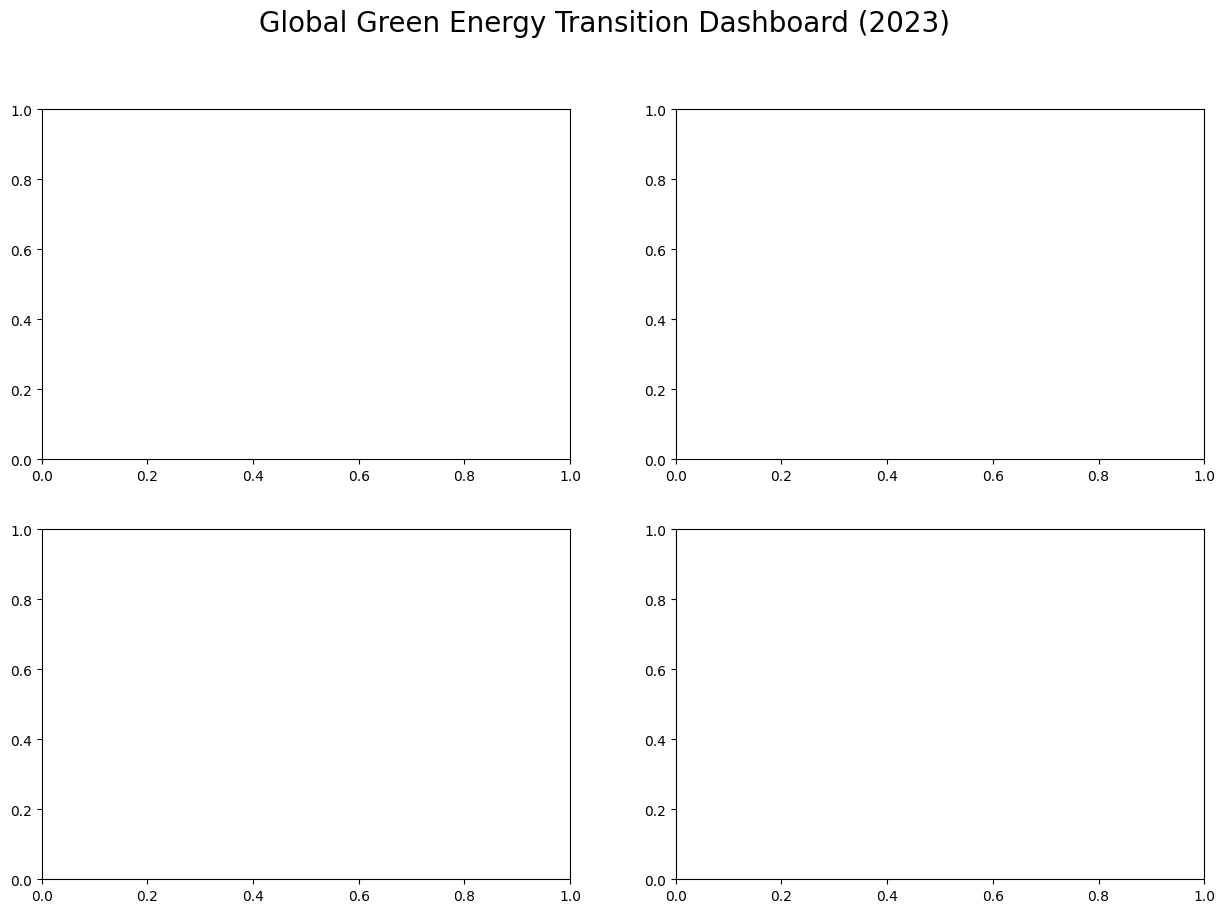

In [41]:
fig , ax = plt.subplots(2,2,figsize=(15,10))
fig.suptitle('Global Green Energy Transition Dashboard (2023)', fontsize=20)

plot on top left graph the green share percentage

In [42]:
ax[0,0].plot(energy_df.index,energy_df['Green_Share_Pct'],alpha=0.5,color="lightgreen",label="Daily") #raw data
ax[0,0].plot(energy_df.index,energy_df['Green_Share_Pct'].rolling(30).mean(),color="darkgreen",label="30-day-trend")#clean
ax[0,0].set_title("Renewable Energy Share %")
ax[0,0].legend()

In [43]:
total_energy = energy_df[col_names].sum()
ax[0, 1].pie(total_energy, labels=col_names, autopct='%1.1f%%', startangle=140, explode=[0.1, 0, 0, 0, 0], colors=['gold', 'skyblue', 'blue', 'gray', 'orange'])
ax[0, 1].set_title('Yearly Energy Mix')

Text(0.5, 1.0, 'Yearly Energy Mix')

In [44]:
ax[1, 0].hist(energy_df['Total_Prod'], bins=30, color='purple', edgecolor='black', alpha=0.7)
ax[1, 0].set_title('Grid Stability (Total Production Distribution)')
ax[1, 0].set_xlabel('Total Units Generated')

Text(0.5, 4.4444444444444375, 'Total Units Generated')

In [45]:
ax[1, 1].scatter(energy_df['Solar'], energy_df['Wind'], alpha=0.5, c=energy_df['Green_Share_Pct'], cmap='viridis')
ax[1, 1].set_title('Solar vs. Wind Correlation')
ax[1, 1].set_xlabel('Solar Output')
ax[1, 1].set_ylabel('Wind Output')

Text(638.5353535353535, 0.5, 'Wind Output')

In [49]:
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<Figure size 640x480 with 0 Axes>

issue with visualistaion fixed

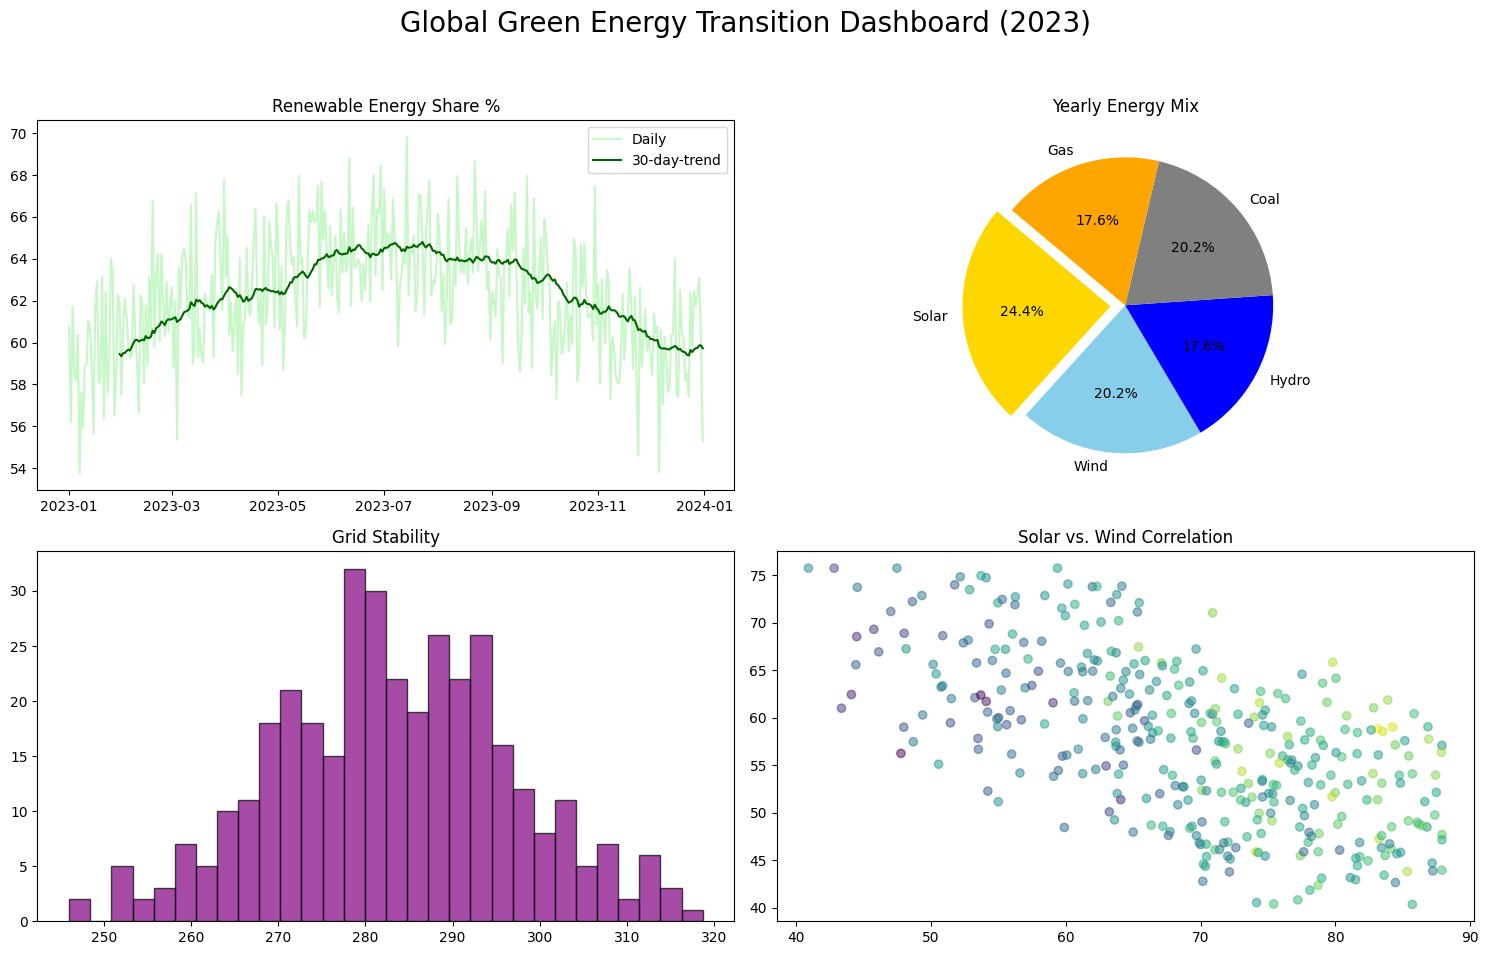

In [50]:
# MERGE THESE INTO ONE CELL
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Global Green Energy Transition Dashboard (2023)', fontsize=20)

# Plot 1: Trend
ax[0, 0].plot(energy_df.index, energy_df['Green_Share_Pct'], alpha=0.5, color="lightgreen", label="Daily")
ax[0, 0].plot(energy_df.index, energy_df['Green_Share_Pct'].rolling(30).mean(), color="darkgreen", label="30-day-trend")
ax[0, 0].set_title("Renewable Energy Share %")
ax[0, 0].legend()

# Plot 2: Mix
total_energy = energy_df[['Solar', 'Wind', 'Hydro', 'Coal', 'Gas']].sum()
ax[0, 1].pie(total_energy, labels=total_energy.index, autopct='%1.1f%%', startangle=140, explode=[0.1, 0, 0, 0, 0], colors=['gold', 'skyblue', 'blue', 'gray', 'orange'])
ax[0, 1].set_title('Yearly Energy Mix')

# Plot 3: Stability
ax[1, 0].hist(energy_df['Total_Prod'], bins=30, color='purple', edgecolor='black', alpha=0.7)
ax[1, 0].set_title('Grid Stability')

# Plot 4: Correlation
ax[1, 1].scatter(energy_df['Solar'], energy_df['Wind'], alpha=0.5, c=energy_df['Green_Share_Pct'], cmap='viridis')
ax[1, 1].set_title('Solar vs. Wind Correlation')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show() # In a single cell, this will trigger the render